# Atmotube Device Report 


This notebook demonstrates how to analyze data from multiple devices of the following type/s: Atmotube. 

## Load and Start

In [1]:
import sys
sys.path.insert(0, "..") # run at repo root
from src.utils import scroll_output # just for output presenation

from src.etl.load import load # calls etl pipeline

MOUNT_PATH = "/home/yul/mnt/proton-data"

# data = load(MOUNT_PATH) # normal usage

data = scroll_output(load, MOUNT_PATH)

### Prep Data and Range

Select the devices and set the datetime range.

In [10]:
from src.utils import consolidate_device_ids, scroll_output, unwrap, merge
from src.stats import filter_date_range

atmotube_consolidated = consolidate_device_ids(data, "Atmotube") # merges all files into one entry per physical device, for Atmotube

list_atmo_ids = list(atmotube_consolidated.keys()) # checking

START = "2026-06-15"
END = "2026-06-30"

def _prepare_atmotube(start=START, end=END):
    """Merge + filter atmotube devices once; reused by every stat below."""
    devices = { # merge all devices together (adds _<device_id> suffixes to columns)
        true_id: unwrap(device)
        for true_id, device in atmotube_consolidated.items()
    }
    merged = merge(**devices)
    return filter_date_range({"": merged}, start=start, end=end)


scroll_output(lambda: ( print(f"====== {START} to {END} ======"), 
                        print(list_atmo_ids)))

(None, None)

## Summary in Total

### Data Loss

This section summarizes the total amount of data loss for every variable per device across the given time range (manually set to filter).

- `rows`: how many total records were present for that device/variable in the date range.
- `missing`: how many of those records are absent/NA for the variable (after filtering).
- `coverage`: the fraction of available (non-missing) samples: `coverage = (rows - missing) / rows * 100`

*Higher coverage* means the descriptive stats are based on more complete data.
*Lower coverage* means global/rolling summaries may be less representative (and can change noticeably depending on whether missingness is random or clustered in time).

column,rows,missing,coverage
longitude,21463,16898,21.269161
latitude,21463,16898,21.269161
timezone,21463,16898,21.269161
altitude,21463,16898,21.269161
pm1_0_ugm3_atm,21463,10992,48.786283
pm2_5_ugm3_atm,21463,10992,48.786283
pm10_ugm3_atm,21463,10992,48.786283
aqs_total,21463,5427,74.714625
temp_c,21463,7089,66.971066
hum_pct,21463,7089,66.971066



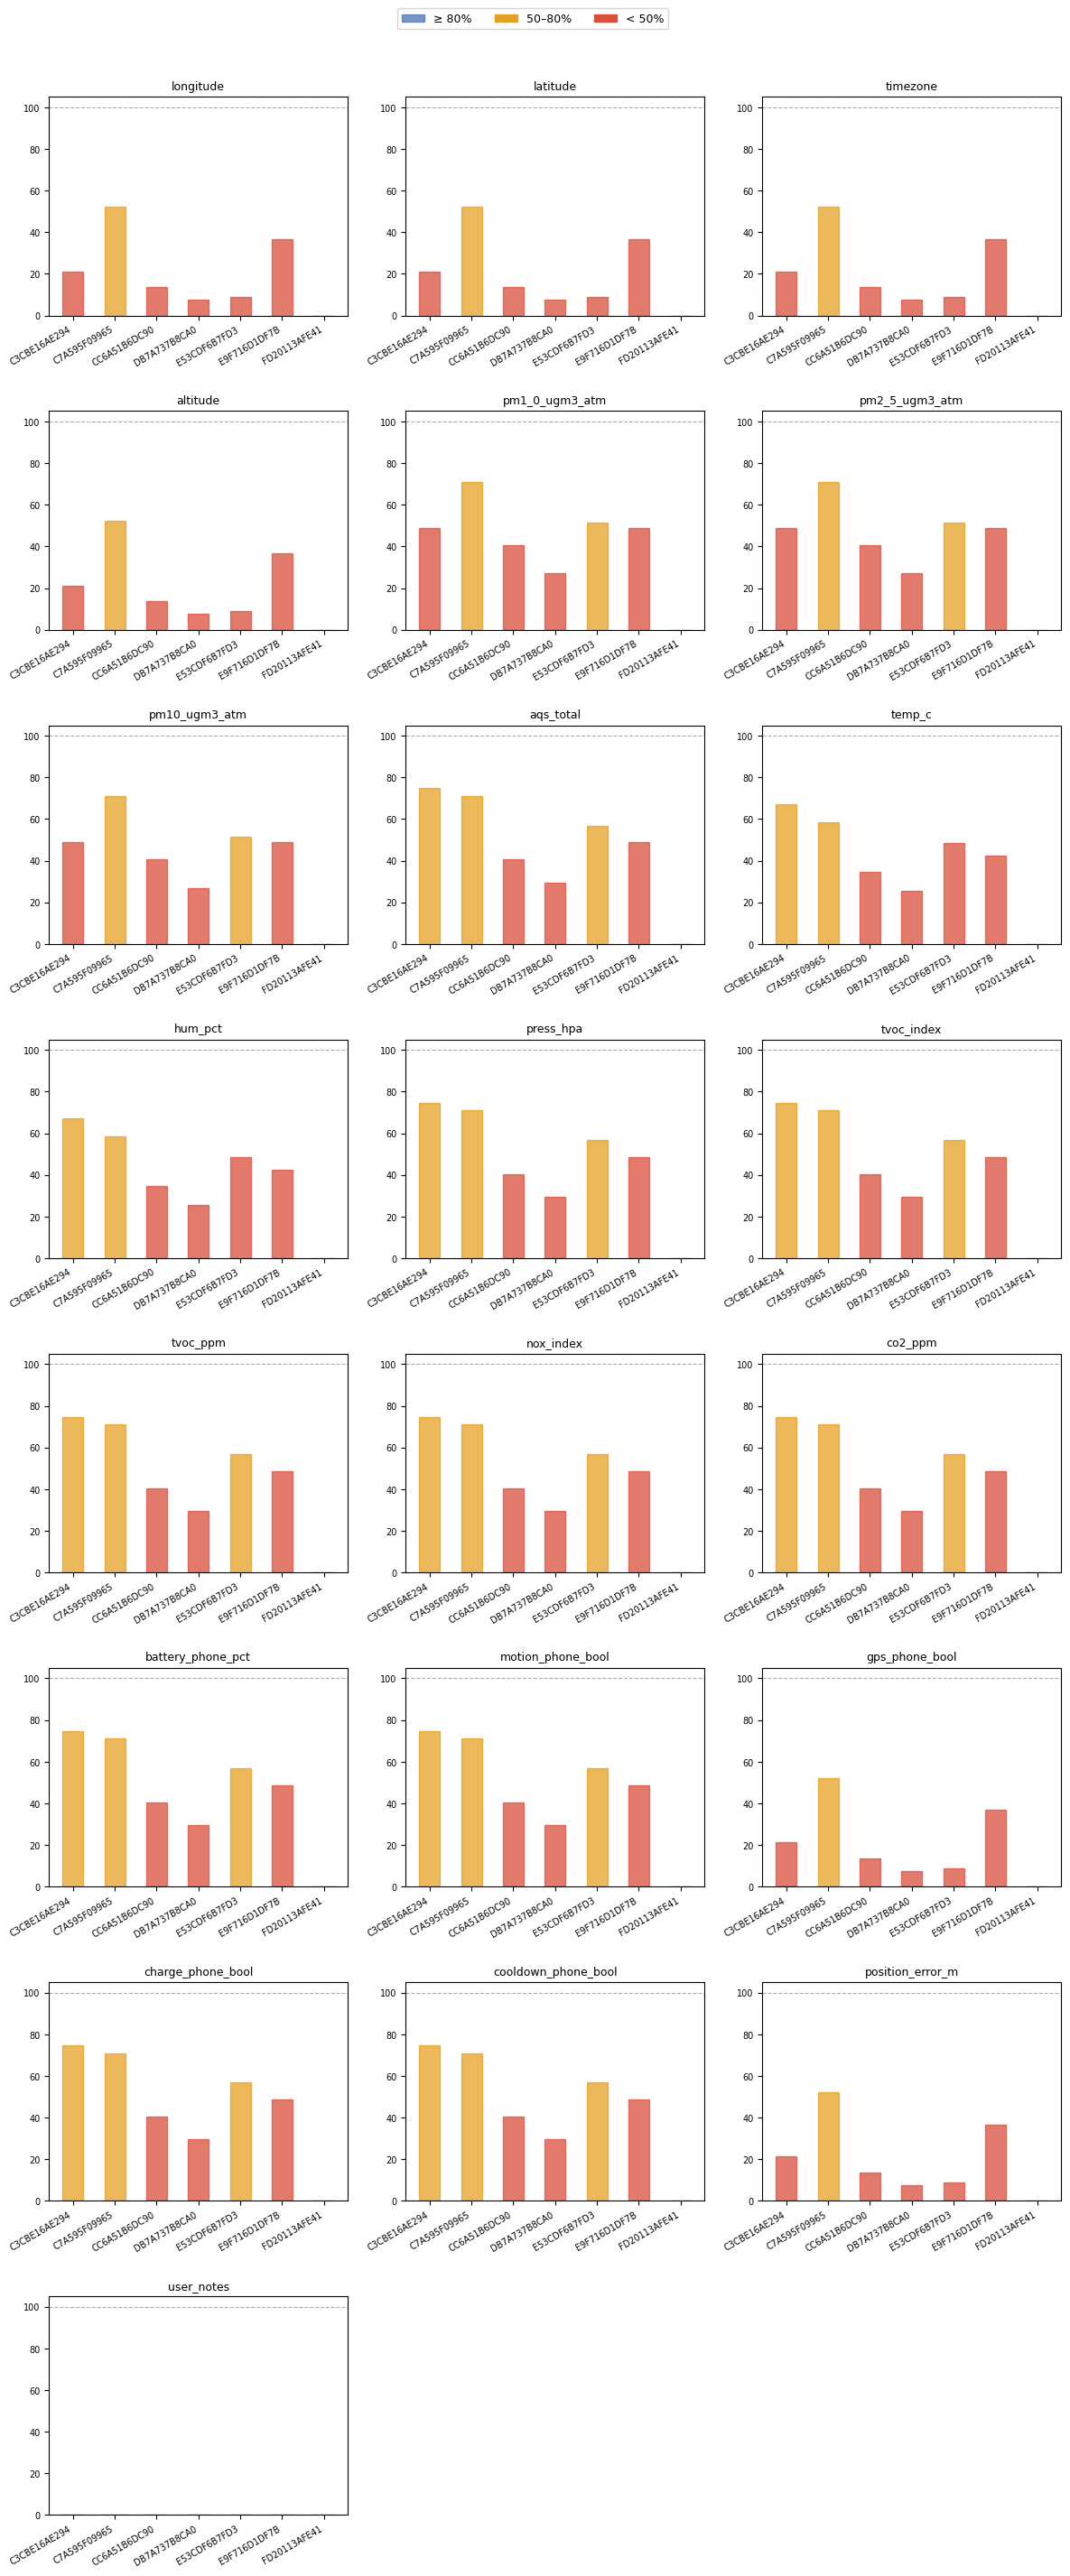

In [7]:
from src.stats import report_loss, plot_loss
from IPython.display import HTML, display

def analyze_atmotube_loss_tables():
    filtered = _prepare_atmotube()
    loss_df = report_loss(filtered)

    # split merged "column" (e.g. "pm1_0_ugm3_atm_C3CBE16AE294") into base + device suffix
    split = loss_df["column"].str.rsplit("_", n=1, expand=True)
    loss_df["base_column"] = split[0]
    loss_df["device_label"] = split[1].fillna("")

    display(HTML(f"<b>====== {START} to {END} ======</b>"))

    ncols = 2
    devices = loss_df["device_label"].unique()
    rows_html = ""

    for i in range(0, len(devices), ncols):
        row_devices = devices[i:i + ncols]
        cells = ""
        for device in row_devices:
            dev_df = loss_df[loss_df["device_label"] == device][["base_column", "rows", "missing", "coverage"]]
            dev_df = dev_df.rename(columns={"base_column": "column"})
            cells += f"""
                <div style="flex: 1; min-width: 0; padding: 0 8px;">
                    <h4> DEVICE {device} </h4>
                    {dev_df.to_html(index=False)}
                </div>
            """
        rows_html += f'<div style="display: flex; gap: 16px; margin-bottom: 24px;">{cells}</div>'

    display(HTML(rows_html))


def analyze_atmotube_loss_plots():
    filtered = _prepare_atmotube()
    loss_df = report_loss(filtered)
    fig = plot_loss(loss_df)

    display(HTML(f"<b>====== {START} to {END} ======</b>"))
    if fig is not None:
        display(fig)


scroll_output(analyze_atmotube_loss_tables)
scroll_output(analyze_atmotube_loss_plots)

### Global Distribution

This section summarizes every numeric variable (excluding boolean and text) per device within a given time range (manually set to filter).

These describe the variable **across the entire time range**: minimum, 25th percentile, median, mean, 75th percentile, and maximum.

The overall distribution for the full period.

column,n,min,q25,median,mean,q75,max
longitude,11217,88.31025,88.36041,88.36045,88.370525,88.36457,88.53614
latitude,11217,22.34263,22.50709,22.50716,22.511662,22.50722,22.90845
altitude,11217,0.00000,0.00000,0.00000,0.000000,0.00000,0.00000
pm1_0_ugm3_atm,15237,0.00000,13.10000,18.60000,23.412667,30.50000,1000.00000
pm2_5_ugm3_atm,15237,0.00000,13.70000,19.60000,24.615928,32.10000,1000.00000
pm10_ugm3_atm,15237,0.00000,13.70000,19.60000,24.702776,32.20000,1000.00000
aqs_total,15241,0.00000,52.00000,61.00000,58.069418,69.00000,100.00000
temp_c,12579,20.10000,30.90000,32.30000,32.747357,33.80000,52.50000
hum_pct,12579,28.00000,61.00000,68.00000,66.502186,74.00000,88.00000
press_hpa,15241,997.50000,1001.30000,1002.50000,1002.497690,1003.80000,1006.70000



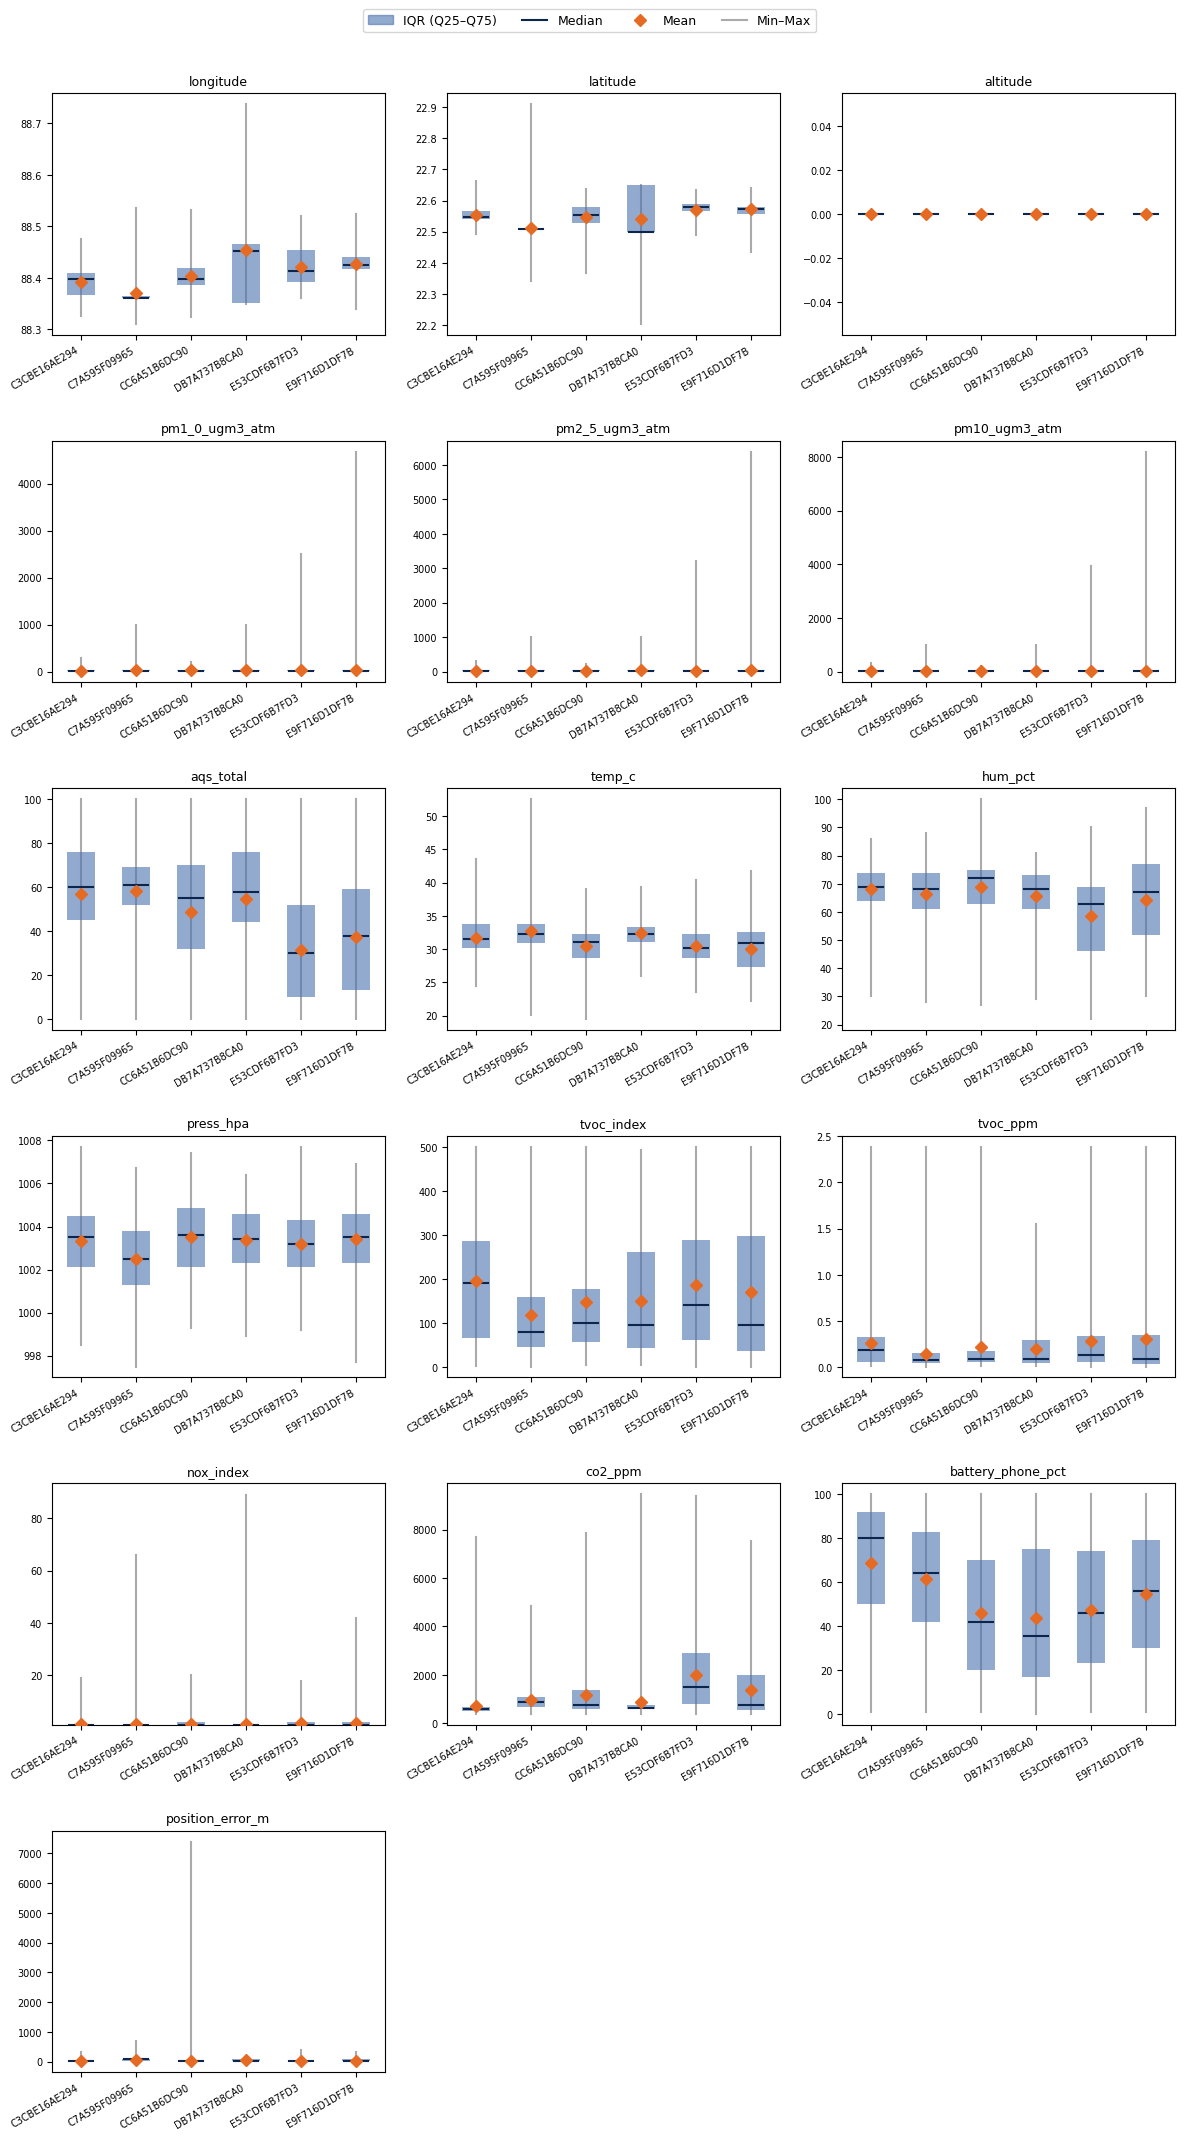

In [14]:
from src.stats import report_global_range, plot_global_range
from IPython.display import HTML, display

def analyze_atmotube_global_tables():
    filtered = _prepare_atmotube()
    global_df = report_global_range(filtered)

    split = global_df["column"].str.rsplit("_", n=1, expand=True)
    global_df["base_column"] = split[0]
    global_df["device_label"] = split[1].fillna("")

    display(HTML(f"<b>====== {START} to {END} ======</b>"))

    ncols = 2
    devices = global_df["device_label"].unique()
    rows_html = ""

    for i in range(0, len(devices), ncols):
        row_devices = devices[i:i + ncols]
        cells = ""
        for device in row_devices:
            dev_df = global_df[global_df["device_label"] == device][
                ["base_column", "n", "min", "q25", "median", "mean", "q75", "max"]
            ]
            dev_df = dev_df.rename(columns={"base_column": "column"})
        cells += f"""
            <div style="flex: 1; min-width: 0; padding: 0 8px; overflow-x: auto;">
                <h4> DEVICE {device} </h4>
                {dev_df.to_html(index=False)}
            </div>
        """
        rows_html += f'<div style="display: flex; gap: 16px; margin-bottom: 24px;">{cells}</div>'

    display(HTML(rows_html))


def analyze_atmotube_global_plots():
    filtered = _prepare_atmotube()
    global_df = report_global_range(filtered)
    fig = plot_global_range(global_df)

    display(HTML(f"<b>====== {START} to {END} ======</b>"))
    if fig is not None:
        display(fig)


scroll_output(analyze_atmotube_global_tables)
scroll_output(analyze_atmotube_global_plots)

## Variation Over Time

### Rolling Windows

This focuses on **local behavior over time** by using a time-based rolling window (e.g., `10D`), but within the same time range.

The distribution of values computed inside rolling time windows — shows the short-term shifts even during stable global distribution.

`roll_min_med`, `roll_center_med`, `roll_max_med` are *typical values of the rolling band* (computed as the median across time of rolling min/center/max).

device,datetime,roll_min,roll_max,roll_mean,roll_median
C3CBE16AE294,2026-06-15 00:00:00+00:00,1000.779663,1003.595560,1001.865028,1001.603419
C7A595F09965,2026-06-15 00:00:00+00:00,1000.488574,1003.081342,1001.639598,1001.506184
CC6A51B6DC90,2026-06-15 00:00:00+00:00,1000.316359,1003.472504,1001.904044,1001.760023
DB7A737B8CA0,2026-06-15 00:00:00+00:00,1000.739471,1003.440617,1001.795426,1001.590176
E53CDF6B7FD3,2026-06-15 00:00:00+00:00,1000.403925,1003.441124,1001.720609,1001.482872
E9F716D1DF7B,2026-06-15 00:00:00+00:00,1000.867051,1003.561137,1001.964454,1001.815323
C3CBE16AE294,2026-06-16 00:00:00+00:00,1000.600000,1005.331207,1003.019198,1003.180570
C7A595F09965,2026-06-16 00:00:00+00:00,999.600000,1004.499669,1002.051572,1001.887417
CC6A51B6DC90,2026-06-16 00:00:00+00:00,999.400000,1005.359442,1002.944643,1003.038837
DB7A737B8CA0,2026-06-16 00:00:00+00:00,1000.500000,1004.745000,1002.672108,1002.790937



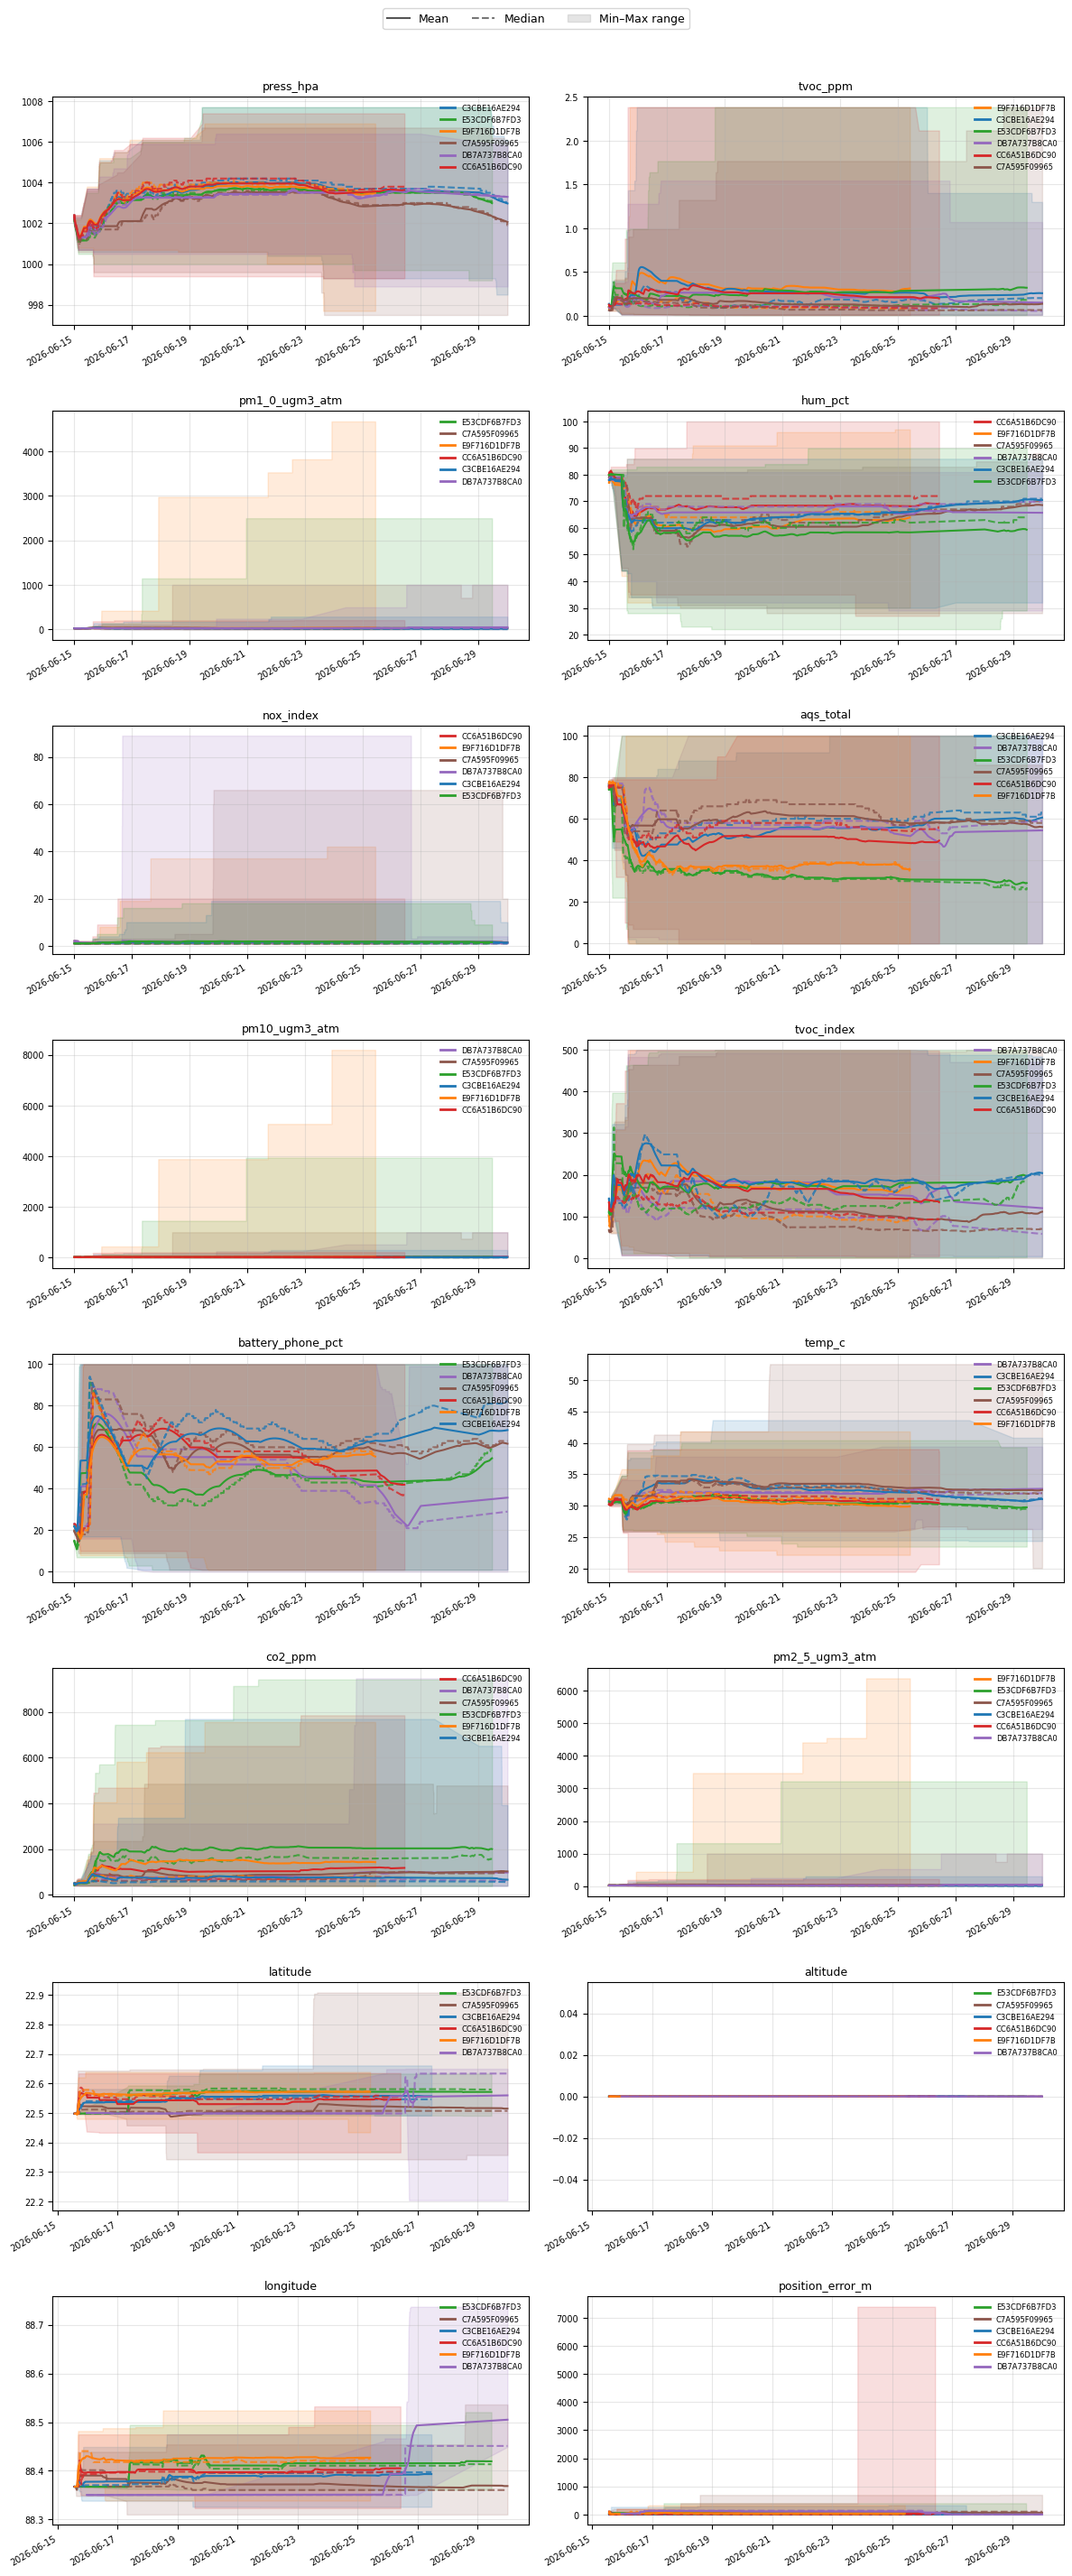

In [20]:
from src.stats import report_rolling_range, plot_rolling_range
from IPython.display import HTML, display

def analyze_atmotube_rolling_tables(window="10D", center="median"):
    filtered = _prepare_atmotube()
    rolling_df = report_rolling_range(filtered, window=window, center=center)

    split = rolling_df["column"].str.rsplit("_", n=1, expand=True)
    rolling_df["base_column"] = split[0]
    rolling_df["device_label"] = split[1].fillna("")

    display(HTML(f"<b>====== {START} to {END} ======</b>"))

    ncols = 1
    groups = list(rolling_df.groupby(["df", "base_column"], sort=False))
    rows_html = ""

    for i in range(0, len(groups), ncols):
        row_groups = groups[i:i + ncols]
        cells = ""
        for (table_name, base_col), grp in row_groups:
            grp_daily = (
                grp.groupby("device_label")
                .resample("D")[["roll_min", "roll_max", "roll_mean", "roll_median"]]
                .mean()
                .reset_index()
                .rename(columns={"device_label": "device"})
                .sort_values(["datetime", "device"])
                .reset_index(drop=True)
            )

            title = f"{table_name}: {base_col}" if table_name else base_col
            cells += f"""
                <div style="flex: 1; min-width: 0; padding: 0 8px; overflow-x: auto;">
                    <h4> {title} </h4>
                    {grp_daily.to_html(index=False)}
                </div>
            """
        rows_html += f'<div style="display: flex; gap: 16px; margin-bottom: 24px;">{cells}</div>'

    display(HTML(rows_html))


def analyze_atmotube_rolling_plots(window="10D", center="median"):
    filtered = _prepare_atmotube()
    rolling_df = report_rolling_range(filtered, window=window, center=center)
    fig = plot_rolling_range(rolling_df)

    display(HTML(f"<b>====== {START} to {END} ======</b>"))
    if fig is not None:
        display(fig)


scroll_output(analyze_atmotube_rolling_tables)
scroll_output(analyze_atmotube_rolling_plots)